<a href="https://colab.research.google.com/github/letienthinh3436/vn-momentum-strategy/blob/main/momentum_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Hypothesis


**MOMENTUM**  - *Cái gì tăng thì nó tiếp tục gia tăng*


**Universe dynamic theo liquidity mỗi tháng**

Tổng quan Strategy
Mỗi tháng:

Tính cho các cổ phiếu VN30

Chọn top N cổ phiếu thanh khoản cao nhất

Chọn top 10 cổ phiếu mometum

Hold 1 tháng

Lặp lại


# 2. Data Collection
Collect historical stock data for all symbols listed on HOSE and HNX exchanges from '2015-01-01' to the current date using `vnstock.Listing` and `vnstock.Quote`, incorporating a 20-second delay between API calls for each symbol, then combine all collected data into a single DataFrame and remove any rows containing missing values.

In [ ]:
!pip install -U vnstock


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.5/277.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00


In [ ]:
# Chạy lệnh và nhập API key theo hướng dẫn
from vnstock import register_user
# register_user()
# hoặc nhập trực tiếp API key vào hàm register_user
register_user('vnstock_db7f72c3f1fe87390c13c31139654f5f')



📋 Connecting Google Drive account
to save project settings.

Mounted at /content/drive
✓ API key đã được lưu thành công! (API key saved successfully!)
Bạn đang sử dụng Phiên bản cộng đồng (60 requests/phút)
(You are using Community version - 60 requests/minute)

Để tham gia gói thành viên tài trợ (To join sponsor membership):
  Truy cập: https://vnstocks.com/insiders-program
✓ API key đã được lưu thành công! vnst***4f5f
✓ Bạn đang sử dụng Phiên bản cộng đồng (60 requests/phút)


True

In [ ]:
# Import các module của vnstock
from vnstock import Listing, Quote, Company, Finance, Trading, Screener

# Cách khác: Import từ nguồn dữ liệu cụ thể
# from vnstock.explorer.vci import Listing, Quote, Company, Finance, Trading
# from vnstock.explorer.tcbs import Quote, Company, Finance, Trading, Screener

print("✅ Tất cả modules đã được import thành công!")

✅ Tất cả modules đã được import thành công!


## Retrieve and Filter Symbols

### Subtask:
Sử dụng `vnstock.Listing` để lấy danh sách các mã cổ phiếu thuộc sàn HOSE và HNX. Sau đó, trích xuất cột 'symbol' và chuyển nó thành một danh sách để sử dụng cho việc lấy dữ liệu lịch sử.


In [ ]:
from vnstock import Listing
import pandas as pd

# 1. Khởi tạo đối tượng Listing
listing = Listing(source='KBS')

# 2. Sử dụng phương thức symbols_by_exchange() để lấy danh sách các mã cổ phiếu thuộc sàn 'HOSE' và 'HNX'
# Dựa trên traceback từ cell sB_2l5PAnMpd, phương thức này trả về một DataFrame.
filtered_symbols_df = listing.symbols_by_exchange(exchange=['HOSE', 'HNX'], type = "stock")

# 3. Từ DataFrame này, trích xuất cột 'symbol' và chuyển nó thành một danh sách.
symbols_to_fetch = filtered_symbols_df['symbol'].tolist()

print(f"Tìm thấy {len(symbols_to_fetch)} mã cổ phiếu trên HOSE và HNX.")
print("Các mã đầu tiên: ", symbols_to_fetch[:10])

Tìm thấy 1980 mã cổ phiếu trên HOSE và HNX.
Các mã đầu tiên:  ['MGC', 'GVT', 'GEG', 'SWC', 'SLD', 'VID', 'PSL', 'TTZ', 'CX8', 'PNJ']


In [ ]:
import time
from datetime import date
from vnstock import Quote

all_data_hose_hnx = []

start_date = '2015-01-01'
end_date = date.today().strftime('%Y-%m-%d') # Get current date as end_date

print(f"Collecting historical data from {start_date} to {end_date} for {len(symbols_to_fetch)} symbols...")

for i, symbol in enumerate(symbols_to_fetch):
    try:
        quote_obj = Quote(symbol=symbol, source='KBS')
        df_symbol = quote_obj.history(start=start_date, end=end_date, interval='d')

        if not df_symbol.empty:
            df_symbol['symbol'] = symbol
            all_data_hose_hnx.append(df_symbol)
            print(f"Successfully fetched data for {symbol} ({i+1}/{len(symbols_to_fetch)}).")
        else:
            print(f"No data found for {symbol} in the specified period ({i+1}/{len(symbols_to_fetch)}).")

    except Exception as e:
        print(f"Error fetching data for {symbol}: {e} ({i+1}/{len(symbols_to_fetch)}).")

    # Add a 8-second delay between API calls
    time.sleep(3)

# Gộp tất cả các DataFrame lại thành một
if all_data_hose_hnx:
    df_hose_hnx = pd.concat(all_data_hose_hnx)
    print("\nAll historical data combined. Head of the raw DataFrame:")
    print(df_hose_hnx.head())

    # Loại bỏ các hàng có giá trị NaN
    df_hose_hnx_cleaned = df_hose_hnx.dropna()
    print("\nDataFrame after removing NaN values. Head of the cleaned DataFrame:")
    print(df_hose_hnx_cleaned.head())
    print("\nInformation about the cleaned DataFrame:")
    print(df_hose_hnx_cleaned.info())
else:
    print("No data was collected.")

Successfully fetched data for MGC (1/1980).
Successfully fetched data for GVT (2/1980).
Successfully fetched data for GEG (3/1980).
Successfully fetched data for SWC (4/1980).
Successfully fetched data for SLD (5/1980).
Successfully fetched data for VID (6/1980).
Successfully fetched data for PSL (7/1980).
Successfully fetched data for TTZ (8/1980).
Successfully fetched data for CX8 (9/1980).

📋 Kết nối tài khoản Google Drive để lưu các thiết lập của dự án.
Dữ liệu phiên làm việc với Colab của bạn sẽ bị xóa nếu không lưu trữ vào Google Drive.

Successfully fetched data for PNJ (10/1980).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully fetched data for TMB (11/1980).
Successfully fetched data for NTH (12/1980).
Successfully fetched data for CVT (13/1980).
Successfully fetched data for POV (14/1980).
Successfully fetched data for SAM (15/1980).
Successfully fetched data for SDV (16/1980).
Succes

2026-03-03 03:08:03 - vnstock.core.utils.client - ERROR - API request failed: HTTPSConnectionPool(host='kbbuddywts.kbsec.com.vn', port=443): Max retries exceeded with url: /iis-server/investment/stocks/DIH/data_day?sdate=01-01-2015&edate=03-03-2026 (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x79c7338ca720>, 'Connection to kbbuddywts.kbsec.com.vn timed out. (connect timeout=30)'))
ERROR:vnstock.core.utils.client:API request failed: HTTPSConnectionPool(host='kbbuddywts.kbsec.com.vn', port=443): Max retries exceeded with url: /iis-server/investment/stocks/DIH/data_day?sdate=01-01-2015&edate=03-03-2026 (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x79c7338ca720>, 'Connection to kbbuddywts.kbsec.com.vn timed out. (connect timeout=30)'))


Successfully fetched data for DIH (1271/1980).
Successfully fetched data for GMX (1272/1980).
Successfully fetched data for PLA (1273/1980).
Successfully fetched data for MDA (1274/1980).
Successfully fetched data for VNF (1275/1980).
Successfully fetched data for SBS (1276/1980).
Successfully fetched data for CRV (1277/1980).
Successfully fetched data for GTA (1278/1980).
Successfully fetched data for DAC (1279/1980).
Successfully fetched data for PSD (1280/1980).
Successfully fetched data for IVS (1281/1980).
Successfully fetched data for HGM (1282/1980).
Successfully fetched data for PTM (1283/1980).
Successfully fetched data for ANT (1284/1980).
Successfully fetched data for CCM (1285/1980).
Successfully fetched data for VBC (1286/1980).
Successfully fetched data for DHC (1287/1980).
Successfully fetched data for LPT (1288/1980).
Successfully fetched data for BHK (1289/1980).
Successfully fetched data for VOS (1290/1980).
Successfully fetched data for TLH (1291/1980).
Successfully 

**Reasoning**:
The previous execution of the data collection process encountered `RetryError` and `ConnectTimeoutError` exceptions, indicating intermittent network issues or API call limits. To address this, I will add `time.sleep(3.5)` at the end of each iteration of the loop for rate limiting and also add `requests.exceptions.RequestException` to the `try-except` block to catch general request errors that might arise during API calls. I'm also changing the initial `all_data_hose_hnx = []` to check if the list already has data (in case of re-execution), and using a temporary list `new_data` to append newly fetched data to avoid clearing previous successful fetches if the cell is re-executed to resume from where it left off, then extending the main list after the loop completes.



In [ ]:
# Chỉ giữ mã "stock" có độ dài 3 hoặc 4 ký tự
df_stock = df_hose_hnx_cleaned[
    df_hose_hnx_cleaned['symbol'].str.len().isin([3, 4])
]

## Tách giá và khối lượng & Lưu trữ vào Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Đảm bảo time là datetime
df_stock['time'] = pd.to_datetime(df_stock['time'])

# Bảng price
df_price = df_stock[['time', 'symbol', 'open', 'high', 'low', 'close']]

# Bảng volume
df_volume = df_stock[['time', 'symbol', 'volume']]


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [ ]:
base_path = "/content/drive/MyDrive/Quant_TienThinh/Project/vn-momentum-strategy/"

df_price.to_parquet(base_path + "price.parquet", index=False)
df_volume.to_parquet(base_path + "volume.parquet", index=False)

## Cleaned dataframe

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from google.colab import drive


In [ ]:
drive.mount('/content/drive')
base_path = "/content/drive/MyDrive/Quant_TienThinh/Project/vn-momentum-strategy/"
daily_price = pd.read_parquet(base_path + "price.parquet")
daily_volume = pd.read_parquet(base_path +"volume.parquet")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Remove duplicate entries for (time, symbol) before pivoting
# Keeping the last entry in case of multiple records for the same day/symbol
daily_price_cleaned = daily_price.drop_duplicates(subset=['time', 'symbol'], keep='last')
daily_volume_cleaned = daily_volume.drop_duplicates(subset=['time', 'symbol'], keep='last')

# Pivot the data, ensuring 'time' becomes the DatetimeIndex
daily_price = daily_price_cleaned.pivot(index='time', columns='symbol', values='close')
daily_volume = daily_volume_cleaned.pivot(index='time', columns='symbol', values='volume')

# Now, drop the last day from the DatetimeIndex of the pivoted DataFrames
daily_price = daily_price.drop(daily_price.index[-1])
daily_volume = daily_volume.drop(daily_volume.index[-1])

In [ ]:
daily_price

symbol,A32,AAA,AAH,AAM,AAS,AAT,AAV,ABB,ABC,ABI,...,XHC,XLV,XMC,XMD,XMP,XPH,YBC,YBM,YEG,YTC
time,,,,,,,,,,,,,,,,,,,,,
2015-09-28 07:00:00,NaN,5.19,NaN,6.10,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.29,4.76,NaN,NaN,NaN
2015-09-29 07:00:00,NaN,5.04,NaN,5.88,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.03,4.76,NaN,NaN,NaN
2015-09-30 07:00:00,NaN,5.04,NaN,5.88,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.03,4.76,NaN,NaN,NaN
2015-10-01 07:00:00,NaN,4.99,NaN,6.22,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.20,4.76,NaN,NaN,NaN
2015-10-02 07:00:00,NaN,5.14,NaN,5.99,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.29,4.76,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24 07:00:00,34.2,8.04,3.2,6.67,10.4,3.25,5.6,13.9,11.1,20.8,...,18.7,13.1,9.5,6.2,16.5,14.50,7.90,10.40,12.30,25.5
2026-02-25 07:00:00,34.2,8.06,3.2,6.50,10.4,3.25,5.6,14.0,11.1,20.9,...,18.7,13.1,9.5,6.2,16.4,14.70,7.40,10.40,12.50,25.5
2026-02-26 07:00:00,34.2,8.06,3.3,6.64,10.5,3.15,5.6,14.0,11.3,20.9,...,18.7,13.1,10.0,6.1,17.0,14.50,7.00,10.55,12.75,24.1


# 3. Signal Construction


## Tính Momentum 6 tháng

In [ ]:
monthly_price = daily_price.resample('ME').last()
monthly_return = monthly_price.pct_change(fill_method=None)
momentum_6m = monthly_price.pct_change(3, fill_method=None)

## Liquidity Dynamic 1 quý



In [ ]:
liquidity = daily_price * daily_volume
avg_liquidity_60d = liquidity.rolling(252).mean()
monthly_liquidity= avg_liquidity_60d.resample('ME').last()

# 4. Portfolio Construction


In [ ]:
portfolio_returns = []

for date in monthly_return.index[6:-1]:

    # --- Liquidity filter ---
    liquid = (
        monthly_liquidity.loc[date]
        .dropna()
        .sort_values(ascending=False)
        .head(100)        # top 100 thanh khoản
        .index
    )

    # --- Momentum trong nhóm liquid ---
    mom = momentum_6m.loc[date, liquid].dropna()

    if len(mom) == 0:
        portfolio_returns.append(np.nan)
        continue

    # --- Chọn top 20% ---
    selected = (
        mom.sort_values(ascending=False)
        .head(int(len(mom)*0.1))
        .index
    )
    # --- Return tháng sau ---
    next_ret = monthly_return.shift(-1).loc[date, selected]
    next_ret = next_ret.dropna()

    if len(next_ret) == 0:
        portfolio_returns.append(np.nan)
    else:
        portfolio_returns.append(next_ret.mean())

In [ ]:
selected

Index(['BSR', 'PLX', 'GAS', 'MSR', 'VGI', 'PVS', 'GVR', 'PVD', 'PC1', 'PNJ'], dtype='object', name='symbol')

# 5. Backtest


In [ ]:
strategy = pd.Series(
    portfolio_returns,
    index=monthly_return.index[6:-1]
)
equity_curve = (1 + strategy).cumprod()

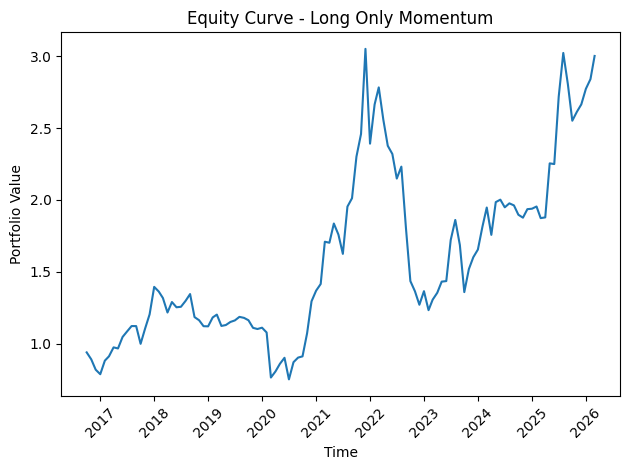

In [ ]:
import matplotlib.pyplot as plt

equity_curve = (1 + strategy).cumprod()

plt.figure()
plt.plot(equity_curve.index, equity_curve.values)
plt.title("Equity Curve - Long Only Momentum")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Performance Metrics, Sensitive Analysis

## Performance Metrics

In [ ]:
annual_return = strategy.mean() * 12
annual_vol = strategy.std() * (12 ** 0.5)
sharpe = annual_return / annual_vol

cum = (1 + strategy).cumprod()
drawdown = cum / cum.cummax() - 1
max_dd =drawdown.min()

annual_return, sharpe, max_dd

(np.float64(0.14323128699896093),
 np.float64(0.5306959328750911),
 -0.5534168093687653)

## Sensitive Analysis

In [ ]:
def run_momentum_strategy(monthly_price,
                          monthly_return,
                          monthly_liquidity,
                          mom_window=12,
                          top_pct=0.2,
                          liquidity_n=100):

    momentum = monthly_price.pct_change(mom_window, fill_method=None)

    portfolio_returns = []

    for date in monthly_return.index[mom_window:-1]:

        # Liquidity filter
        liquid = (
            monthly_liquidity.loc[date]
            .dropna()
            .sort_values(ascending=False)
            .head(liquidity_n)
            .index
        )

        # Momentum selection
        mom = momentum.loc[date, liquid].dropna()

        if len(mom) == 0:
            portfolio_returns.append(np.nan)
            continue

        selected = (
            mom.sort_values(ascending=False)
            .head(int(len(mom) * top_pct))
            .index
        )

        # Next month return
        next_ret = monthly_return.shift(-1).loc[date, selected]
        next_ret = next_ret.dropna()

        if len(next_ret) == 0:
            portfolio_returns.append(np.nan)
        else:
            portfolio_returns.append(next_ret.mean())

    strategy = pd.Series(
        portfolio_returns,
        index=monthly_return.index[mom_window:-1]
    )

    return strategy

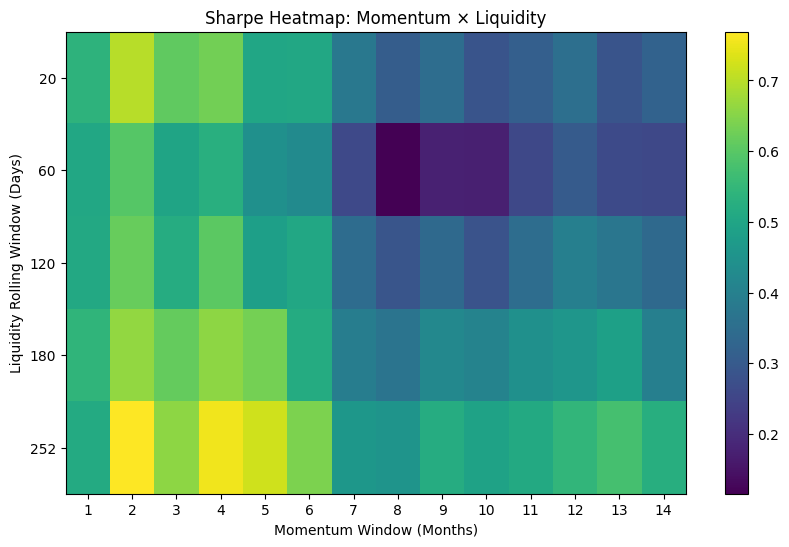

In [ ]:
mom_windows = range(1, 15)                 # 1–15 tháng
liq_windows = [20,60, 120, 180, 252]          # 3m, 6m, 9m, 1y (daily)

top_pct = 0.2

results = []

for m in mom_windows:
    for lw in liq_windows:

        # ===== Recalculate liquidity =====
        liquidity = daily_price * daily_volume
        avg_liquidity = liquidity.rolling(lw).mean()
        monthly_liquidity = avg_liquidity.resample('ME').last()

        strategy = run_momentum_strategy(
            monthly_price,
            monthly_return,
            monthly_liquidity,
            mom_window=m,
            top_pct=top_pct
        )

        if len(strategy) < 12:
            continue

        annual_return = strategy.mean() * 12
        annual_vol = strategy.std() * np.sqrt(12)
        sharpe = annual_return / annual_vol if annual_vol != 0 else np.nan

        results.append({
            "Momentum": m,
            "LiquidityWindow": lw,
            "Sharpe": sharpe
        })

results_df = pd.DataFrame(results)

# Pivot
heatmap_data = results_df.pivot(
    index="LiquidityWindow",
    columns="Momentum",
    values="Sharpe"
)

# Plot
plt.figure(figsize=(10,6))
plt.imshow(heatmap_data, aspect='auto')
plt.colorbar()

plt.xticks(range(len(heatmap_data.columns)),
           heatmap_data.columns)

plt.yticks(range(len(heatmap_data.index)),
           heatmap_data.index)

plt.xlabel("Momentum Window (Months)")
plt.ylabel("Liquidity Rolling Window (Days)")
plt.title("Sharpe Heatmap: Momentum × Liquidity")
plt.show()

# 7. Improve & Optimize